In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torchaudio
import os
import corner


# Emociones

In [2]:
labels = pd.read_csv("Emociones/Podcast/labels.csv")

print(labels.head())
print(labels.info())
print(labels.describe())

          path partition  activation  valence  dominance
0  train/0.wav     train         4.2    4.000      4.000
1  train/1.wav     train         5.0    2.000      6.000
2  train/2.wav     train         4.6    4.600      4.800
3  train/3.wav     train         4.5    4.333      4.333
4  train/4.wav     train         6.4    1.400      6.400
<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   path        6000 non-null   str    
 1   partition   6000 non-null   str    
 2   activation  6000 non-null   float64
 3   valence     6000 non-null   float64
 4   dominance   6000 non-null   float64
dtypes: float64(3), str(2)
memory usage: 234.5 KB
None
        activation      valence    dominance
count  6000.000000  6000.000000  6000.000000
mean      4.518292     3.910115     4.606068
std       0.997212     1.058821     0.947430
min       1.000000     1.000000     1.000

In [3]:
print("Número total de audios:", len(labels))

print("\nAudios por partición:")
print(labels["partition"].value_counts())

print("\nPorcentaje:")
print(labels["partition"].value_counts(normalize=True) * 100)

Número total de audios: 6000

Audios por partición:
partition
train         4200
validation    1200
test           600
Name: count, dtype: int64

Porcentaje:
partition
train         70.0
validation    20.0
test          10.0
Name: proportion, dtype: float64


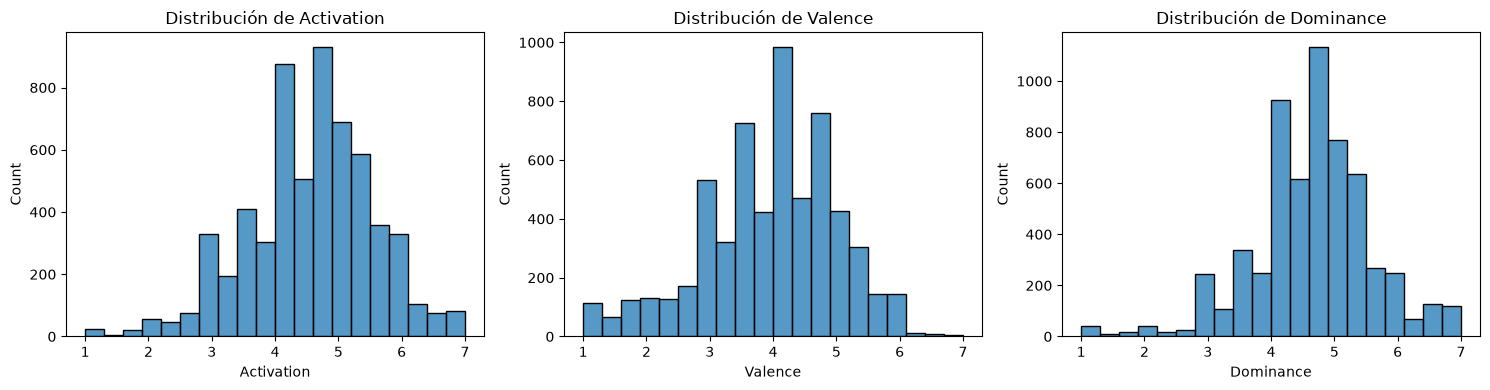

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(labels["activation"], bins=20, ax=axes[0])
axes[0].set_title("Distribución de Activation")
axes[0].set_xlabel("Activation")

sns.histplot(labels["valence"], bins=20, ax=axes[1])
axes[1].set_title("Distribución de Valence")
axes[1].set_xlabel("Valence")

sns.histplot(labels["dominance"], bins=20, ax=axes[2])
axes[2].set_title("Distribución de Dominance")
axes[2].set_xlabel("Dominance")

plt.tight_layout()
plt.show()

            activation   valence  dominance
activation    1.000000  0.009763   0.816934
valence       0.009763  1.000000  -0.057410
dominance     0.816934 -0.057410   1.000000


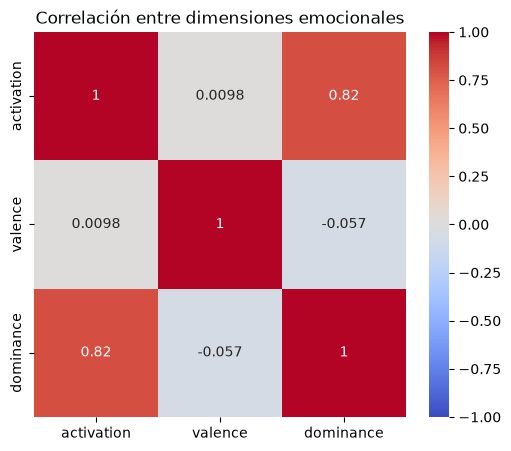

In [5]:
corr = labels[["activation", "valence", "dominance"]].corr()

print(corr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlación entre dimensiones emocionales")
plt.show()

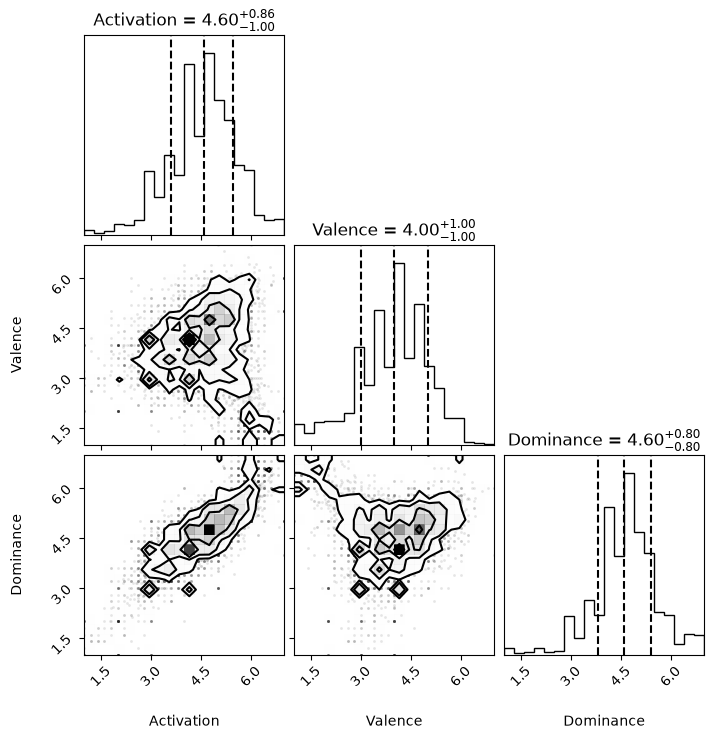

In [6]:
labels = pd.read_csv("Emociones/Podcast/labels.csv")

data = labels[
    ["activation", "valence", "dominance"]
].values

figure = corner.corner(
    data,
    labels=["Activation", "Valence", "Dominance"],
    show_titles=True,
    title_fmt=".2f",
    quantiles=[0.16, 0.50, 0.84],
    title_kwargs={"fontsize": 12}
)

plt.show()

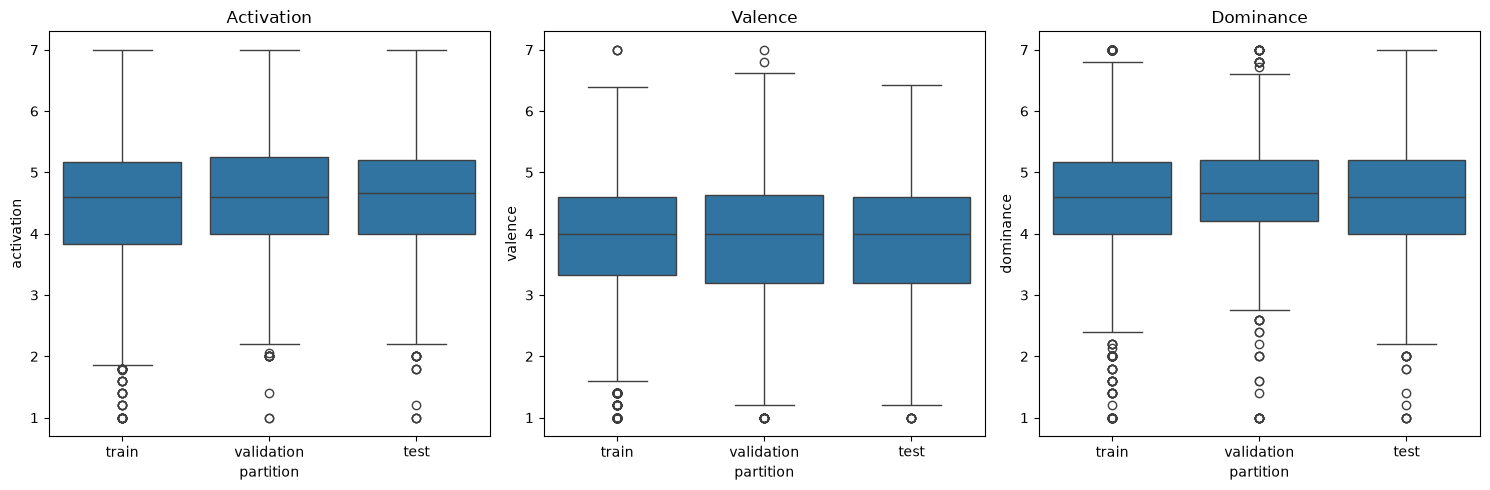

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(
    data=labels,
    x="partition",
    y="activation",
    ax=axes[0]
)
axes[0].set_title("Activation")

sns.boxplot(
    data=labels,
    x="partition",
    y="valence",
    ax=axes[1]
)
axes[1].set_title("Valence")

sns.boxplot(
    data=labels,
    x="partition",
    y="dominance",
    ax=axes[2]
)
axes[2].set_title("Dominance")

plt.tight_layout()
plt.show()

# Audios

In [8]:
durations = []
sample_rates = []
channels = []

for path in labels["path"]:

    audio_path = os.path.join("Emociones/Podcast/", path)

    waveform, sample_rate = torchaudio.load(audio_path)

    duration = waveform.shape[1] / sample_rate

    durations.append(duration)
    sample_rates.append(sample_rate)
    channels.append(waveform.shape[0])

labels["duration"] = durations

print(labels.head())
print(labels.info())
print(labels.describe())

          path partition  activation  valence  dominance  duration
0  train/0.wav     train         4.2    4.000      4.000  4.866937
1  train/1.wav     train         5.0    2.000      6.000  9.600000
2  train/2.wav     train         4.6    4.600      4.800  7.000063
3  train/3.wav     train         4.5    4.333      4.333  9.984000
4  train/4.wav     train         6.4    1.400      6.400  3.456000
<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   path        6000 non-null   str    
 1   partition   6000 non-null   str    
 2   activation  6000 non-null   float64
 3   valence     6000 non-null   float64
 4   dominance   6000 non-null   float64
 5   duration    6000 non-null   float64
dtypes: float64(4), str(2)
memory usage: 281.4 KB
None
        activation      valence    dominance     duration
count  6000.000000  6000.000000  6000.000000  6000.000000
mean

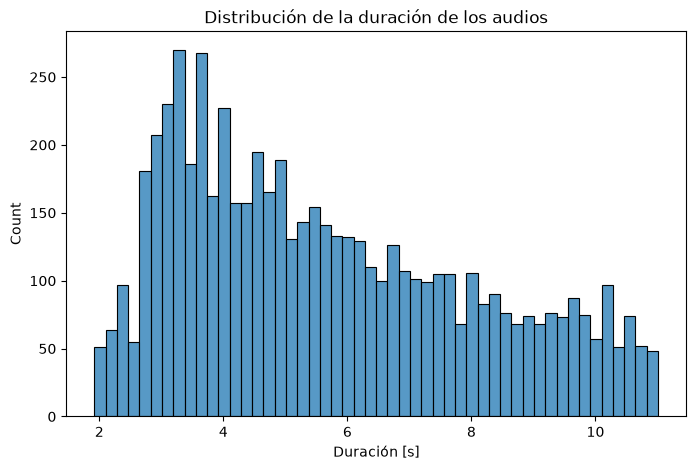

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(
    labels["duration"],
    bins=50
)

plt.xlabel("Duración [s]")
plt.title("Distribución de la duración de los audios")

plt.show()

In [10]:
sr_counts = pd.Series(sample_rates).value_counts().sort_index()

print(sr_counts)

16000    6000
Name: count, dtype: int64


In [11]:
print(pd.Series(channels).value_counts().sort_index())

1    6000
Name: count, dtype: int64


            duration  activation   valence  dominance
duration    1.000000    0.011182 -0.068233   0.060647
activation  0.011182    1.000000  0.009763   0.816934
valence    -0.068233    0.009763  1.000000  -0.057410
dominance   0.060647    0.816934 -0.057410   1.000000


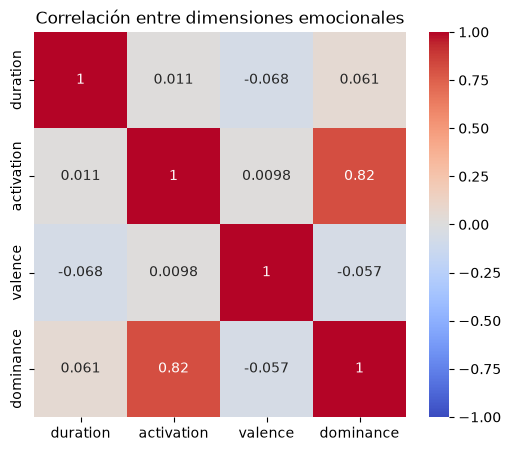

In [12]:
corr = labels[
    ["duration", "activation", "valence", "dominance"]
].corr()

print(corr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlación entre dimensiones emocionales")
plt.show()